In [3]:
import pandas as pd
from google.colab import files
uploaded=files.upload()
df=pd.read_csv("ford_car_dataset.csv")

Saving ford_car_dataset.csv to ford_car_dataset.csv


In [4]:
import pandas as pd

# Load Dataset
df = pd.read_csv("ford_car_dataset.csv")

# First 10 rows
print(df.head(10))

# Last 5 rows
print(df.tail())

# Shape
print("Shape:", df.shape)

# Data Types
print(df.dtypes)

     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
5   Fiesta  2015  10500       Manual    35432   Petrol  145  47.9         1.6
6     Puma  2019  22500       Manual     2029   Petrol  145  50.4         1.0
7   Fiesta  2017   9000       Manual    13054   Petrol  145  54.3         1.2
8     Kuga  2019  25500    Automatic     6894   Diesel  145  42.2         2.0
9    Focus  2018  10000       Manual    48141   Petrol  145  61.4         1.0
        model  year  price transmission  mileage fuelType  tax   mpg  \
17961   B-MAX  2017   8999       Manual    16700   Petrol  150  47.1  

In [5]:
# Missing values
print(df.isnull().sum())

# Duplicate rows
print(df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print(df.shape)

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64
154
(17812, 9)


In [6]:
print(df.describe())

print("Minimum Values")
print(df[['price','mileage','year']].min())

print("Maximum Values")
print(df[['price','mileage','year']].max())

print("Mean Values")
print(df[['price','mileage','year']].mean())

print("Median Values")
print(df[['price','mileage','year']].median())

               year         price        mileage           tax           mpg  \
count  17812.000000  17812.000000   17812.000000  17812.000000  17812.000000   
mean    2016.862396  12269.556310   23381.146362    113.315012     57.908696   
std        2.052039   4736.285417   19419.011045     62.034603     10.132696   
min     1996.000000    495.000000       1.000000      0.000000     20.800000   
25%     2016.000000   8999.000000   10000.000000     30.000000     52.300000   
50%     2017.000000  11288.000000   18277.000000    145.000000     58.900000   
75%     2018.000000  15295.000000   31098.500000    145.000000     65.700000   
max     2060.000000  54995.000000  177644.000000    580.000000    201.800000   

         engineSize  
count  17812.000000  
mean       1.350623  
std        0.432581  
min        0.000000  
25%        1.000000  
50%        1.200000  
75%        1.500000  
max        5.000000  
Minimum Values
price       495
mileage       1
year       1996
dtype: int64
Maxim

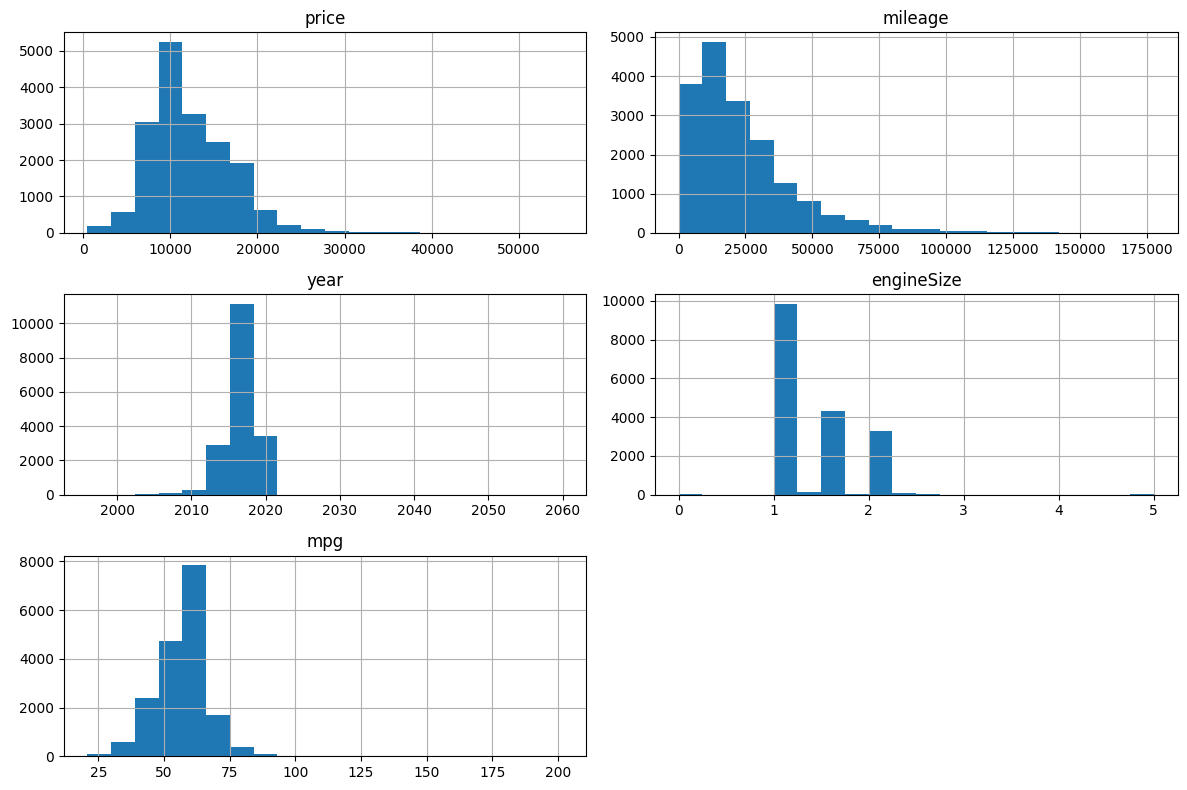

In [7]:
import matplotlib.pyplot as plt

cols=['price','mileage','year','engineSize','mpg']

df[cols].hist(figsize=(12,8),bins=20)

plt.tight_layout()
plt.show()

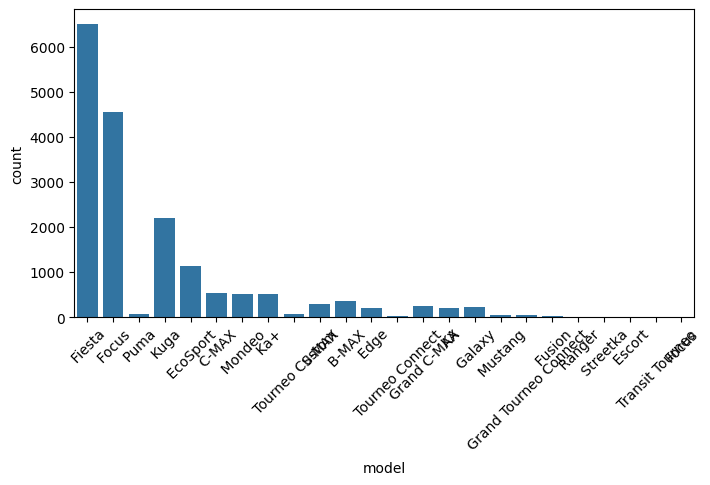

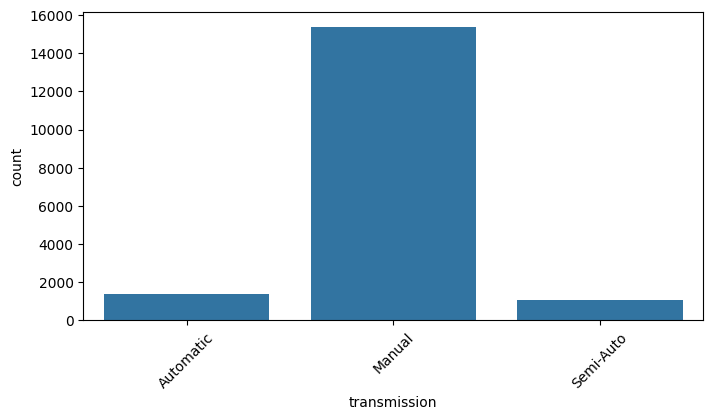

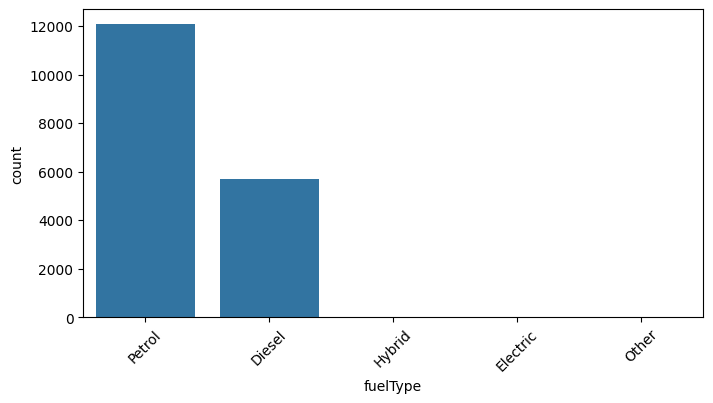

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

cat=df.select_dtypes(include='object').columns

for col in cat:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col,data=df)
    plt.xticks(rotation=45)
    plt.show()

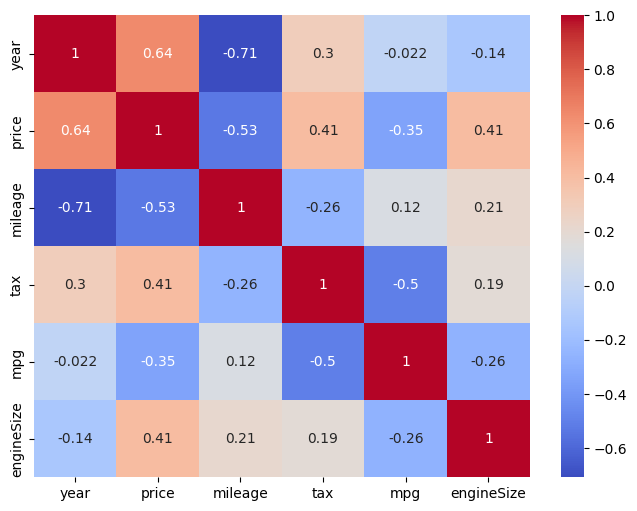

In [9]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

In [10]:
print(df[['model','fuelType']].head())

encoded_df=pd.get_dummies(df,drop_first=True)

print(encoded_df.head())

     model fuelType
0   Fiesta   Petrol
1    Focus   Petrol
2    Focus   Petrol
3   Fiesta   Petrol
4   Fiesta   Petrol
   year  price  mileage  tax   mpg  engineSize  model_ C-MAX  model_ EcoSport  \
0  2017  12000    15944  150  57.7         1.0         False            False   
1  2018  14000     9083  150  57.7         1.0         False            False   
2  2017  13000    12456  150  57.7         1.0         False            False   
3  2019  17500    10460  145  40.3         1.5         False            False   
4  2019  16500     1482  145  48.7         1.0         False            False   

   model_ Edge  model_ Escort  ...  model_ Tourneo Connect  \
0        False          False  ...                   False   
1        False          False  ...                   False   
2        False          False  ...                   False   
3        False          False  ...                   False   
4        False          False  ...                   False   

   model_ Tourneo Cu

In [11]:
from sklearn.preprocessing import StandardScaler

X=encoded_df.drop("price",axis=1)

num_cols=['year','mileage','tax','mpg','engineSize']

scaler=StandardScaler()

X[num_cols]=scaler.fit_transform(X[num_cols])

print(X.head())

       year   mileage       tax       mpg  engineSize  model_ C-MAX  \
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561         False   
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561         False   
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561         False   
3  1.041726 -0.665405  0.510777 -1.737858    0.345325         False   
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561         False   

   model_ EcoSport  model_ Edge  model_ Escort  model_ Fiesta  ...  \
0            False        False          False           True  ...   
1            False        False          False          False  ...   
2            False        False          False          False  ...   
3            False        False          False           True  ...   
4            False        False          False           True  ...   

   model_ Tourneo Connect  model_ Tourneo Custom  model_ Transit Tourneo  \
0                   False                  False                   False   


model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64
       year   mileage       tax       mpg  engineSize  model_ C-MAX  \
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561         False   
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561         False   
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561         False   
3  1.041726 -0.665405  0.510777 -1.737858    0.345325         False   
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561         False   

   model_ EcoSport  model_ Edge  model_ Escort  model_ Fiesta  ...  \
0            False        False          False           True  ...   
1            False        False          False          False  ...   
2            False        False          False          False  ...   
3            False        False          False           True  ...   
4            False        False          False  

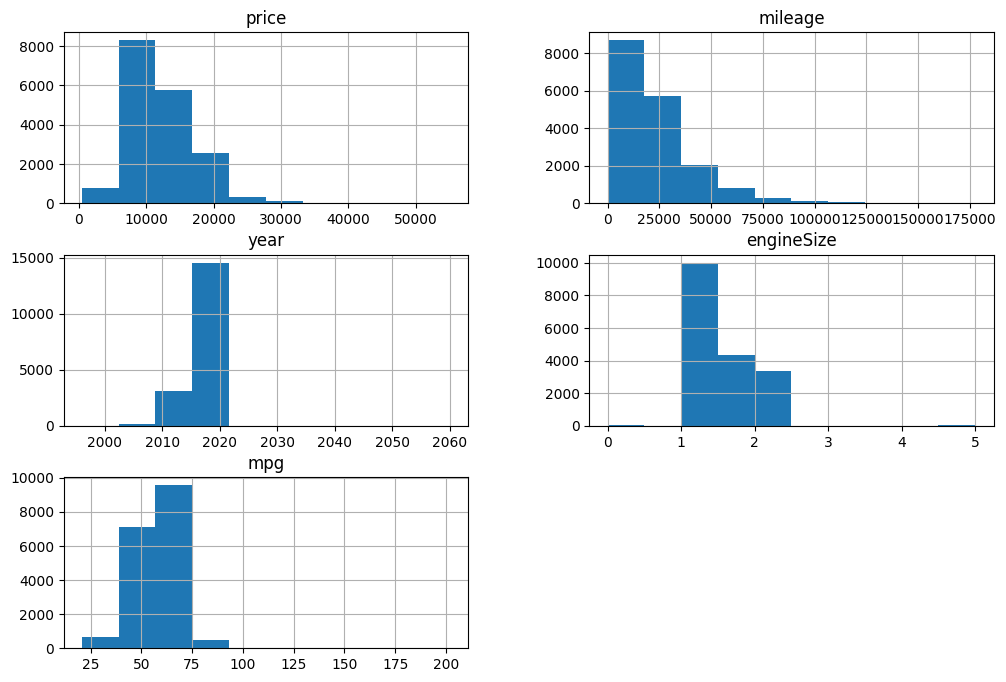

In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load
df=pd.read_csv("ford_car_dataset.csv")

# Remove duplicates
df=df.drop_duplicates()

# Missing values
print(df.isnull().sum())

# Histograms
df[['price','mileage','year','engineSize','mpg']].hist(figsize=(12,8))

# Encode
df=pd.get_dummies(df,drop_first=True)

# Features
X=df.drop('price',axis=1)
y=df['price']

# Scaling
scaler=StandardScaler()

cols=['year','mileage','tax','mpg','engineSize']

X[cols]=scaler.fit_transform(X[cols])

print(X.head())